# Baseline Model Training

This notebook runs the first end-to-end baseline pass:

- load the latest raw dataset by default
- validate and clean the raw rows
- engineer the first-pass features
- split by `user_id`
- train the baseline classifier and regressor
- save processed datasets and serialized model artifacts
- inspect baseline metrics and feature importances

Typical workflow:

1. Run the imports/setup cell.
2. Run the preview cell.
3. Run `TRAINING_RESULT = train_default_baseline()`.
4. Inspect metrics, artifact paths, and feature importances below.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml.features import find_latest_raw_csv, load_dataset_preview
from ml.train import run_baseline_training

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

DEFAULT_RAW_CSV = find_latest_raw_csv(REPO_ROOT / 'data' / 'raw')
DEFAULT_PROCESSED_ROOT = REPO_ROOT / 'data' / 'processed'
DEFAULT_MODELS_ROOT = REPO_ROOT / 'models'
DEFAULT_RANDOM_SEED = 42

print('Repo root:', REPO_ROOT)
print('Default raw CSV:', DEFAULT_RAW_CSV)


Repo root: C:\Users\nayut\OneDrive\Документы\osu-skill-predictor
Default raw CSV: C:\Users\nayut\OneDrive\Документы\osu-skill-predictor\data\raw\osu_country_try_data_full_20260601T074107Z\osu_country_try_data_v1.csv


In [2]:
raw_preview = load_dataset_preview(DEFAULT_RAW_CSV, n_rows=5)
display(Markdown(f'**Raw CSV:** `{DEFAULT_RAW_CSV.relative_to(REPO_ROOT)}`'))
display(raw_preview)

profiling_summary_path = DEFAULT_RAW_CSV.parent / 'profiling_summary.md'
if profiling_summary_path.exists():
    display(Markdown('## Profiling Summary'))
    display(Markdown(profiling_summary_path.read_text(encoding='utf-8')))


**Raw CSV:** `data\raw\osu_country_try_data_full_20260601T074107Z\osu_country_try_data_v1.csv`

,row_id,score_id,user_id,beatmap_id,beatmapset_id,ruleset,collected_at,score_created_at,score_source,seed_country_code,seed_country_rank,seed_country_player_rank,seed_global_rank,target_passed,target_accuracy,score_rank,mods_raw,observed_pp,observed_max_combo,count_300,count_100,count_50,count_miss,user_pp,user_global_rank,user_country_rank,user_accuracy,user_play_count,user_play_time_sec,user_total_hits,user_maximum_combo,beatmap_star_rating,beatmap_bpm,beatmap_ar,beatmap_od,beatmap_cs,beatmap_hp,beatmap_hit_length_sec,beatmap_total_length_sec,beatmap_count_circles,beatmap_count_sliders,beatmap_count_spinners,beatmap_status,beatmap_passcount,beatmap_playcount
0,5019360540,5019360540,4175698,5258382,2401111,osu,2026-06-01T08:26:36Z,2026-05-02T18:53:54Z,best,US,1,1,7,True,97.0340,S,NC,1775.17,2427,1849,76,8,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,7.02593,190.00,9.5,9.2,4.0,5.0,238,260,1682,251,0,ranked,16908,182260
1,4934854295,4934854295,4175698,5211120,2191876,osu,2026-06-01T08:26:36Z,2025-11-08T00:54:22Z,best,US,1,1,7,True,98.4942,S,DT,1630.13,644,476,11,0,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,7.12841,200.00,9.7,9.5,4.3,5.0,58,59,393,94,0,ranked,17180,144559
2,4888133395,4888133395,4175698,5065131,2353052,osu,2026-06-01T08:26:36Z,2025-08-13T16:46:40Z,best,US,1,1,7,True,97.5970,A,NC,1608.47,2175,2502,87,4,1,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.73248,200.00,9.5,9.1,3.8,5.5,416,424,1914,679,1,ranked,8898,165331
3,4887078214,4887078214,4175698,4704022,2219231,osu,2026-06-01T08:26:36Z,2025-08-11T18:02:30Z,best,US,1,1,7,True,98.0301,S,DT,1515.03,2406,1783,48,5,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.34169,200.00,9.4,9.0,4.0,5.0,210,211,1598,238,0,ranked,44124,653617
4,4918857637,4918857637,4175698,5119288,2364885,osu,2026-06-01T08:26:36Z,2025-10-08T21:19:15Z,best,US,1,1,7,True,98.2456,S,DT,1464.59,1675,1221,33,0,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.60982,189.99,9.4,9.2,3.9,5.1,152,152,1071,182,1,ranked,30748,355825


## Profiling Summary

# Profiling Summary

Dataset: `osu_country_try_data_v1.csv`

## Collection Metadata

- Source: official osu! API v2
- Ruleset: `osu`
- Export started at: `2026-06-01T07:41:07Z`
- Export finished at: `2026-06-01T12:27:33Z`
- Export duration seconds: `17186.0`
- Earliest row collected_at: `2026-06-01T08:26:36Z`
- Latest row collected_at: `2026-06-01T12:09:01Z`
- Ranking type: `performance`
- Random seed: `42`
- Top country count: `100`
- Players per country: `100`
- Country ranking max: `10000`
- Country sample mean ratio: `0.5`
- Country sample std ratio: `0.2`
- Country leaderboard size: `233`
- Recent scores per user: `30`
- Best scores per user: `20`

## Size

- Rows: `184615`
- Unique users: `10000`
- Unique beatmaps: `35430`
- Sampled users requested: `10000`
- Unique sampled users: `10000`
- Processed users: `10000`

## Sampled Users Per Country

- `AE`: `100`
- `AR`: `100`
- `AT`: `100`
- `AU`: `100`
- `BA`: `100`
- `BD`: `100`
- `BE`: `100`
- `BG`: `100`
- `BH`: `100`
- `BN`: `100`
- `BO`: `100`
- `BR`: `100`
- `BY`: `100`
- `CA`: `100`
- `CH`: `100`
- `CL`: `100`
- `CN`: `100`
- `CO`: `100`
- `CR`: `100`
- `CY`: `100`
- `CZ`: `100`
- `DE`: `100`
- `DK`: `100`
- `DO`: `100`
- `DZ`: `100`
- `EC`: `100`
- `EE`: `100`
- `EG`: `100`
- `ES`: `100`
- `FI`: `100`
- `FR`: `100`
- `GB`: `100`
- `GE`: `100`
- `GR`: `100`
- `GT`: `100`
- `HK`: `100`
- `HN`: `100`
- `HR`: `100`
- `HU`: `100`
- `ID`: `100`
- `IE`: `100`
- `IL`: `100`
- `IN`: `100`
- `IQ`: `100`
- `IS`: `100`
- `IT`: `100`
- `JO`: `100`
- `JP`: `100`
- `KG`: `100`
- `KH`: `100`
- `KR`: `100`
- `KW`: `100`
- `KZ`: `100`
- `LT`: `100`
- `LU`: `100`
- `LV`: `100`
- `MA`: `100`
- `MD`: `100`
- `MK`: `100`
- `MM`: `100`
- `MN`: `100`
- `MO`: `100`
- `MV`: `100`
- `MX`: `100`
- `MY`: `100`
- `NL`: `100`
- `NO`: `100`
- `NP`: `100`
- `NZ`: `100`
- `PA`: `100`
- `PE`: `100`
- `PH`: `100`
- `PK`: `100`
- `PL`: `100`
- `PR`: `100`
- `PT`: `100`
- `PY`: `100`
- `QA`: `100`
- `RE`: `100`
- `RO`: `100`
- `RS`: `100`
- `RU`: `100`
- `SA`: `100`
- `SE`: `100`
- `SG`: `100`
- `SI`: `100`
- `SK`: `100`
- `SV`: `100`
- `TH`: `100`
- `TN`: `100`
- `TR`: `100`
- `TT`: `100`
- `TW`: `100`
- `UA`: `100`
- `US`: `100`
- `UY`: `100`
- `UZ`: `100`
- `VE`: `100`
- `VN`: `100`
- `ZA`: `100`

## Processed Users Per Country

- `AE`: `100`
- `AR`: `100`
- `AT`: `100`
- `AU`: `100`
- `BA`: `100`
- `BD`: `100`
- `BE`: `100`
- `BG`: `100`
- `BH`: `100`
- `BN`: `100`
- `BO`: `100`
- `BR`: `100`
- `BY`: `100`
- `CA`: `100`
- `CH`: `100`
- `CL`: `100`
- `CN`: `100`
- `CO`: `100`
- `CR`: `100`
- `CY`: `100`
- `CZ`: `100`
- `DE`: `100`
- `DK`: `100`
- `DO`: `100`
- `DZ`: `100`
- `EC`: `100`
- `EE`: `100`
- `EG`: `100`
- `ES`: `100`
- `FI`: `100`
- `FR`: `100`
- `GB`: `100`
- `GE`: `100`
- `GR`: `100`
- `GT`: `100`
- `HK`: `100`
- `HN`: `100`
- `HR`: `100`
- `HU`: `100`
- `ID`: `100`
- `IE`: `100`
- `IL`: `100`
- `IN`: `100`
- `IQ`: `100`
- `IS`: `100`
- `IT`: `100`
- `JO`: `100`
- `JP`: `100`
- `KG`: `100`
- `KH`: `100`
- `KR`: `100`
- `KW`: `100`
- `KZ`: `100`
- `LT`: `100`
- `LU`: `100`
- `LV`: `100`
- `MA`: `100`
- `MD`: `100`
- `MK`: `100`
- `MM`: `100`
- `MN`: `100`
- `MO`: `100`
- `MV`: `100`
- `MX`: `100`
- `MY`: `100`
- `NL`: `100`
- `NO`: `100`
- `NP`: `100`
- `NZ`: `100`
- `PA`: `100`
- `PE`: `100`
- `PH`: `100`
- `PK`: `100`
- `PL`: `100`
- `PR`: `100`
- `PT`: `100`
- `PY`: `100`
- `QA`: `100`
- `RE`: `100`
- `RO`: `100`
- `RS`: `100`
- `RU`: `100`
- `SA`: `100`
- `SE`: `100`
- `SG`: `100`
- `SI`: `100`
- `SK`: `100`
- `SV`: `100`
- `TH`: `100`
- `TN`: `100`
- `TR`: `100`
- `TT`: `100`
- `TW`: `100`
- `UA`: `100`
- `US`: `100`
- `UY`: `100`
- `UZ`: `100`
- `VE`: `100`
- `VN`: `100`
- `ZA`: `100`

## Target Distribution

- Passed: `181010`
- Failed: `3605`
- Pass rate: `98.0473%`

## Numeric Summary

- `target_accuracy`
  - mean: `89.5277`
  - median: `92.9078`
  - min: `0.0000`
  - max: `100.0000`
- `beatmap_star_rating`
  - mean: `3.9074`
  - median: `3.8900`
  - min: `0.1384`
  - max: `189.2150`
- `beatmap_bpm`
  - mean: `165.7043`
  - median: `174.0000`
  - min: `34.0000`
  - max: `500.0000`

## Score Sources

- `best`: `177920`
- `recent`: `6695`

## Rows Per Country

- `AE`: `1619`
- `AR`: `2062`
- `AT`: `1957`
- `AU`: `2076`
- `BA`: `1527`
- `BD`: `1661`
- `BE`: `2045`
- `BG`: `1673`
- `BH`: `1790`
- `BN`: `1886`
- `BO`: `1577`
- `BR`: `2131`
- `BY`: `2085`
- `CA`: `2018`
- `CH`: `1796`
- `CL`: `2090`
- `CN`: `2200`
- `CO`: `2044`
- `CR`: `1738`
- `CY`: `1765`
- `CZ`: `2052`
- `DE`: `2172`
- `DK`: `1786`
- `DO`: `1658`
- `DZ`: `1553`
- `EC`: `1905`
- `EE`: `1746`
- `EG`: `1452`
- `ES`: `2097`
- `FI`: `2086`
- `FR`: `2215`
- `GB`: `2106`
- `GE`: `1300`
- `GR`: `1611`
- `GT`: `1605`
- `HK`: `2083`
- `HN`: `1552`
- `HR`: `1812`
- `HU`: `2085`
- `ID`: `2080`
- `IE`: `1649`
- `IL`: `1762`
- `IN`: `2016`
- `IQ`: `1338`
- `IS`: `1645`
- `IT`: `2090`
- `JO`: `1650`
- `JP`: `2123`
- `KG`: `1575`
- `KH`: `1670`
- `KR`: `2113`
- `KW`: `1711`
- `KZ`: `2140`
- `LT`: `1895`
- `LU`: `1711`
- `LV`: `1757`
- `MA`: `1600`
- `MD`: `1600`
- `MK`: `1656`
- `MM`: `1618`
- `MN`: `1337`
- `MO`: `1832`
- `MV`: `1692`
- `MX`: `2034`
- `MY`: `2063`
- `NL`: `2066`
- `NO`: `1881`
- `NP`: `1731`
- `NZ`: `1868`
- `PA`: `1741`
- `PE`: `2132`
- `PH`: `2148`
- `PK`: `1589`
- `PL`: `2220`
- `PR`: `1584`
- `PT`: `2062`
- `PY`: `1638`
- `QA`: `1672`
- `RE`: `1823`
- `RO`: `2027`
- `RS`: `1819`
- `RU`: `2168`
- `SA`: `1483`
- `SE`: `2092`
- `SG`: `2054`
- `SI`: `1842`
- `SK`: `1652`
- `SV`: `1602`
- `TH`: `2020`
- `TN`: `1593`
- `TR`: `2037`
- `TT`: `1802`
- `TW`: `2077`
- `UA`: `2254`
- `US`: `2272`
- `UY`: `1632`
- `UZ`: `1421`
- `VE`: `1925`
- `VN`: `2199`
- `ZA`: `1516`

## Top Mods

- `NM`: `147783`
- `DT`: `8492`
- `HD`: `5281`
- `HDDT`: `5062`
- `HR`: `4519`
- `NF`: `3216`
- `HDHR`: `1416`
- `HRDT`: `1155`
- `NC`: `1029`
- `TD`: `860`

## Observations

- This export uses deterministic country-local rank sampling, so re-running with the same config should preserve the sampled user pool.
- `seed_country_player_rank` is the sampled local rank inside the country leaderboard, while `seed_global_rank` keeps the player's global position at sampling time.
- The public country player rankings endpoint currently exposes only the top `10000` users per country, so `country_ranking_max` must stay within that coverage.
- JSONL storage keeps raw data append-friendly and much easier to inspect than large directories of tiny JSON files.
- `best` score rows improve positive-label coverage, but source mix should be tracked during training.
- Resume safety comes from append-only user snapshots, beatmap cache reuse, and state.json checkpoints.


In [3]:
def train_default_baseline(
    raw_csv_path=None,
    processed_root=DEFAULT_PROCESSED_ROOT,
    models_root=DEFAULT_MODELS_ROOT,
    random_seed=DEFAULT_RANDOM_SEED,
):
    return run_baseline_training(
        raw_csv_path=raw_csv_path or DEFAULT_RAW_CSV,
        processed_root=processed_root,
        models_root=models_root,
        random_seed=random_seed,
    )


In [4]:
TRAINING_RESULT = train_default_baseline()
TRAINING_RESULT


{'raw_csv_path': WindowsPath('C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/raw/osu_country_try_data_full_20260601T074107Z/osu_country_try_data_v1.csv'),
 'processed_dir': WindowsPath('C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/processed/osu_country_try_data_full_20260601T074107Z'),
 'models_dir': WindowsPath('C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/models'),
 'cleaning_report': {'rows_loaded': 184615,
  'rows_dropped_missing_required': 0,
  'rows_dropped_ruleset': 0,
  'rows_dropped_score_source': 0,
  'rows_dropped_domain': 1,
  'rows_dropped_duplicate_row_id': 385,
  'rows_kept': 184229},
 'dataset_metadata_path': WindowsPath('C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/processed/osu_country_try_data_full_20260601T074107Z/dataset_metadata.json'),
 'model_metadata_path': WindowsPath('C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/models/model_metadata.json'),
 'classifier_metrics': {'pr_auc': 0.9942376098306691,
  'roc_

In [5]:
artifact_summary = pd.DataFrame(
    [
        ('raw_csv_path', str(TRAINING_RESULT['raw_csv_path'].relative_to(REPO_ROOT))),
        ('processed_dir', str(TRAINING_RESULT['processed_dir'].relative_to(REPO_ROOT))),
        ('models_dir', str(TRAINING_RESULT['models_dir'].relative_to(REPO_ROOT))),
        ('dataset_metadata_path', str(TRAINING_RESULT['dataset_metadata_path'].relative_to(REPO_ROOT))),
        ('model_metadata_path', str(TRAINING_RESULT['model_metadata_path'].relative_to(REPO_ROOT))),
        ('classifier_path', str(TRAINING_RESULT['classifier_path'].relative_to(REPO_ROOT))),
        ('regressor_path', str(TRAINING_RESULT['regressor_path'].relative_to(REPO_ROOT))),
    ],
    columns=['artifact', 'path'],
)
display(Markdown('## Saved Artifacts'))
display(artifact_summary)

cleaning_report = pd.DataFrame(
    TRAINING_RESULT['cleaning_report'].items(),
    columns=['check', 'value'],
)
display(Markdown('## Cleaning Report'))
display(cleaning_report)

split_counts = pd.DataFrame(
    TRAINING_RESULT['split_counts'].items(),
    columns=['split_name', 'rows'],
)
display(Markdown('## Split Counts'))
display(split_counts)


## Saved Artifacts

,artifact,path
0,raw_csv_path,data\raw\osu_country_try_data_full_20260601T07...
1,processed_dir,data\processed\osu_country_try_data_full_20260...
2,models_dir,models
3,dataset_metadata_path,data\processed\osu_country_try_data_full_20260...
4,model_metadata_path,models\model_metadata.json
5,classifier_path,models\pass_model.joblib
6,regressor_path,models\accuracy_model.joblib


## Cleaning Report

,check,value
0,rows_loaded,184615
1,rows_dropped_missing_required,0
2,rows_dropped_ruleset,0
3,rows_dropped_score_source,0
4,rows_dropped_domain,1
5,rows_dropped_duplicate_row_id,385
6,rows_kept,184229


## Split Counts

,split_name,rows
0,train,147301
1,test,36928


In [6]:
classifier_metrics = pd.DataFrame(
    TRAINING_RESULT['classifier_metrics'].items(),
    columns=['metric', 'value'],
)
regressor_metrics = pd.DataFrame(
    TRAINING_RESULT['regressor_metrics'].items(),
    columns=['metric', 'value'],
)
display(Markdown('## Classifier Metrics'))
display(classifier_metrics)
display(Markdown('## Regressor Metrics'))
display(regressor_metrics)


## Classifier Metrics

,metric,value
0,pr_auc,0.994238
1,roc_auc,0.788871
2,f1,0.991803
3,precision,0.987411
4,recall,0.996234
5,positive_rate_test,0.985025
6,predicted_positive_rate,0.993826


## Regressor Metrics

,metric,value
0,mae,3.474767
1,rmse,5.982957
2,r2,0.675560
3,prediction_min,18.549253
4,prediction_max,99.985741


## Classifier Feature Importances

,feature,importance
0,numeric__beatmap_passcount,0.147992
1,numeric__beatmap_playcount,0.123762
2,numeric__beatmap_star_rating,0.096951
3,numeric__star_gap,0.088063
4,numeric__user_pp,0.084211
5,numeric__user_play_count,0.082080
6,numeric__user_accuracy,0.081026
7,numeric__beatmap_hit_length_sec,0.054136
8,numeric__beatmap_total_length_sec,0.050940
9,numeric__beatmap_ar,0.048147


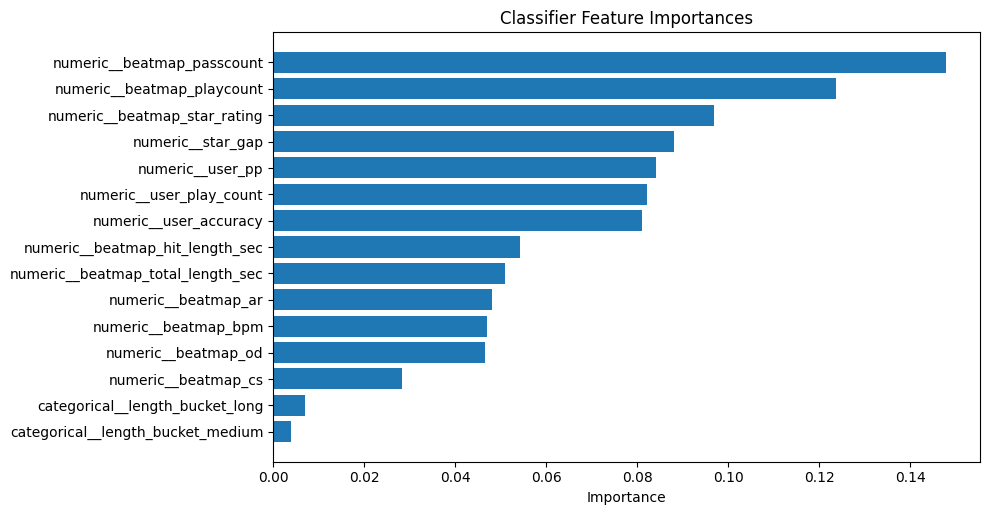

## Regressor Feature Importances

,feature,importance
0,numeric__user_accuracy,0.690044
1,numeric__star_gap,0.102718
2,numeric__user_play_count,0.032695
3,numeric__user_pp,0.032129
4,numeric__beatmap_passcount,0.023652
5,numeric__beatmap_star_rating,0.019471
6,numeric__beatmap_playcount,0.017823
7,numeric__beatmap_bpm,0.017110
8,numeric__beatmap_hit_length_sec,0.015104
9,numeric__beatmap_total_length_sec,0.014129


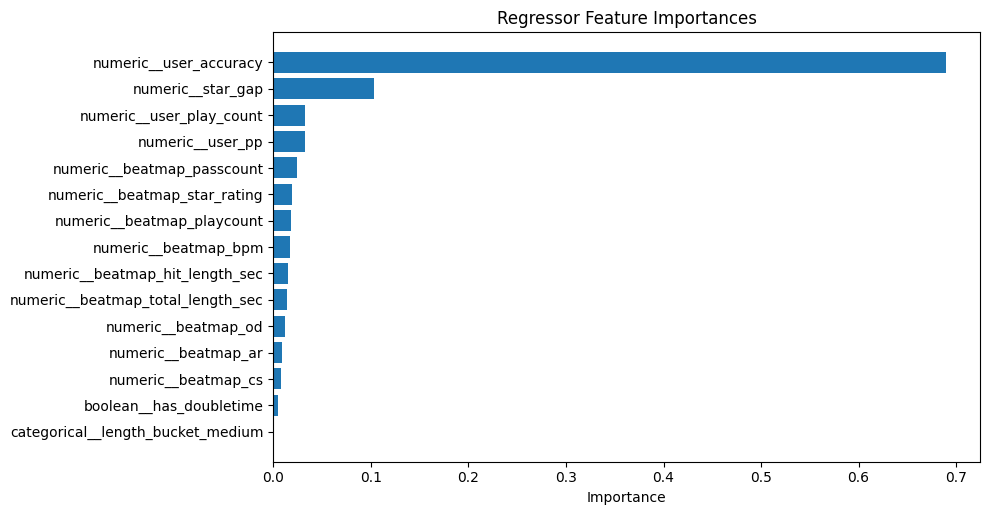

In [7]:
def plot_top_importances(importance_df, title, top_n=15):
    top = importance_df.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.35)))
    ax.barh(top['feature'], top['importance'])
    ax.set_title(title)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

display(Markdown('## Classifier Feature Importances'))
display(TRAINING_RESULT['classifier_feature_importance'].head(20))
plot_top_importances(TRAINING_RESULT['classifier_feature_importance'], 'Classifier Feature Importances')

display(Markdown('## Regressor Feature Importances'))
display(TRAINING_RESULT['regressor_feature_importance'].head(20))
plot_top_importances(TRAINING_RESULT['regressor_feature_importance'], 'Regressor Feature Importances')


In [8]:
model_metadata = json.loads(Path(TRAINING_RESULT['model_metadata_path']).read_text(encoding='utf-8'))
dataset_metadata = json.loads(Path(TRAINING_RESULT['dataset_metadata_path']).read_text(encoding='utf-8'))

display(Markdown('## Model Metadata'))
display(model_metadata)

display(Markdown('## Dataset Metadata'))
display(dataset_metadata)


## Model Metadata

{'artifact_version': 'v1',
 'trained_at': '2026-06-06T14:51:47Z',
 'source_raw_csv': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/raw/osu_country_try_data_full_20260601T074107Z/osu_country_try_data_v1.csv',
 'source_processed_dir': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/processed/osu_country_try_data_full_20260601T074107Z',
 'split_strategy': 'grouped_user_shuffle_v1',
 'split_random_seed': 42,
 'feature_columns': ['user_pp',
  'user_accuracy',
  'user_play_count',
  'beatmap_star_rating',
  'beatmap_bpm',
  'beatmap_ar',
  'beatmap_od',
  'beatmap_cs',
  'beatmap_hit_length_sec',
  'beatmap_total_length_sec',
  'beatmap_passcount',
  'beatmap_playcount',
  'star_gap',
  'has_hidden',
  'has_hardrock',
  'has_doubletime',
  'length_bucket'],
 'artifacts': {'pass_model': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/models/pass_model.joblib',
  'accuracy_model': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/models/accuracy_model.jobl

## Dataset Metadata

{'artifact_version': 'v1',
 'processed_at': '2026-06-06T14:51:47Z',
 'source_raw_csv': 'C:/Users/nayut/OneDrive/Документы/osu-skill-predictor/data/raw/osu_country_try_data_full_20260601T074107Z/osu_country_try_data_v1.csv',
 'row_counts': {'loaded': 184615,
  'cleaned': 184229,
  'train': 147301,
  'test': 36928},
 'unique_counts': {'users': 9999, 'beatmaps': 35261},
 'split': {'strategy': 'grouped_user_shuffle_v1',
  'random_seed': 42,
  'test_ratio': 0.2},
 'feature_columns': ['user_pp',
  'user_accuracy',
  'user_play_count',
  'beatmap_star_rating',
  'beatmap_bpm',
  'beatmap_ar',
  'beatmap_od',
  'beatmap_cs',
  'beatmap_hit_length_sec',
  'beatmap_total_length_sec',
  'beatmap_passcount',
  'beatmap_playcount',
  'star_gap',
  'has_hidden',
  'has_hardrock',
  'has_doubletime',
  'length_bucket'],
 'target_columns': ['target_passed', 'target_accuracy'],
 'cleaning_report': {'rows_loaded': 184615,
  'rows_dropped_missing_required': 0,
  'rows_dropped_ruleset': 0,
  'rows_dropped